In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df06 = pd.read_excel("DADOS_PARANA.xlsx",sheet_name="2006")
df16 = pd.read_excel("DADOS_PARANA.xlsx",sheet_name="2021")
df23 = pd.read_excel("DADOS_PARANA.xlsx",sheet_name="2023")

for i in ['DT_PROPOSTA', 'DT_INICIO_VIGENCIA', 'DT_FIM_VIGENCIA', 'DT_APOLICE']:
    df06[i] = pd.to_datetime(df06[i],format='%d/%m/%Y')

In [8]:
col = ['ID_PROPOSTA','NM_SEGURADO','DT_INICIO_VIGENCIA', 'DT_FIM_VIGENCIA','NM_MUNICIPIO_PROPRIEDADE','LATITUDE', 'NR_GRAU_LAT', 'NR_MIN_LAT',
       'NR_SEG_LAT', 'LONGITUDE', 'NR_GRAU_LONG', 'NR_MIN_LONG', 'NR_SEG_LONG','NM_CLASSIF_PRODUTO','NM_CULTURA_GLOBAL','NR_AREA_TOTAL','VL_SUBVENCAO_FEDERAL','VALOR_INDENIZAÇÃO','EVENTO_PREPONDERANTE']

df06 = df06[col]
df16 = df16[col]
df23 = df23[col]

df = pd.concat([df06,df16,df23])

df['LATITUDE'] = df['LATITUDE'].replace("-",np.nan)
df['LONGITUDE'] = df['LONGITUDE'].replace("-",np.nan)

df = df.dropna(subset=['LATITUDE','LONGITUDE'])

df["EVENTO_PREPONDERANTE"] = df["EVENTO_PREPONDERANTE"].str.replace("\xa0", "")\
    .str.strip()

print(df["EVENTO_PREPONDERANTE"].unique())

df = df[~df["EVENTO_PREPONDERANTE"].isin(['VENTOS FORTES/FRIOS','VENTOS FORTES'])]

['GEADA' 'CHUVA EXCESSIVA' 'SECA' 'GRANIZO' 'VENTOS FORTES/FRIOS'
 'INUNDAÇÃO/TROMBA D´ÁGUA' 'VARIAÇÃO EXCESSIVA DE TEMPERATURA'
 'VENTOS FORTES' 'RAIO']


In [9]:
def dms_to_dd(degrees, minutes, seconds, direction):
    """
    Converts latitude or longitude from DMS (degrees, minutes, seconds) format to DD (decimal degrees).
    
    Parameters:
        degrees (int): Degrees component.
        minutes (int): Minutes component.
        seconds (float): Seconds component.
        direction (str): 'N', 'S', 'E', or 'W' to specify hemisphere.
        
    Returns:
        float: Decimal degrees.
    """
    # Calculate decimal degrees
    decimal_degrees = degrees + (minutes / 60) + (seconds / 3600)
    
    # Adjust for direction
    if direction in ['S', 'W']:
        decimal_degrees *= -1
    
    return decimal_degrees

df['LONGITUDE'] = df.apply(lambda x: dms_to_dd(x['NR_GRAU_LONG'], x['NR_MIN_LONG'], x['NR_SEG_LONG'], x['LONGITUDE']), axis=1)
df['LATITUDE'] = df.apply(lambda x: dms_to_dd(x['NR_GRAU_LAT'], x['NR_MIN_LAT'], x['NR_SEG_LAT'], x['LATITUDE']), axis=1)
df.drop(['NR_GRAU_LAT', 'NR_MIN_LAT', 'NR_SEG_LAT', 'NR_GRAU_LONG', 'NR_MIN_LONG', 'NR_SEG_LONG'], axis=1, inplace=True)
df = df[(df['LATITUDE']!=0) | (df['LONGITUDE']!=0)]

df = df.dropna(subset=['LATITUDE','LONGITUDE'])

In [13]:
df = df[df["DT_INICIO_VIGENCIA"]!=df["DT_FIM_VIGENCIA"	]]

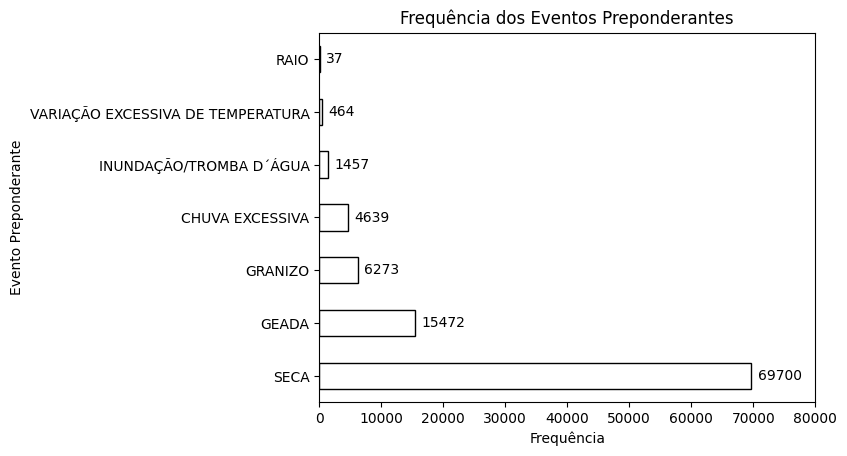

In [15]:
ax = df['EVENTO_PREPONDERANTE'].value_counts().plot(
    kind='barh',
    color='none',  # Barras brancas
    edgecolor='black'  # Contorno preto
)

# Ajustar o fundo do gráfico para ser transparente
ax.set_facecolor('none')  # Fundo do eixo
plt.gcf().patch.set_alpha(0)  # Fundo da figura principal

# Adicionar os valores no final de cada barra
for i, v in enumerate(df['EVENTO_PREPONDERANTE'].value_counts()):
    ax.text(v + 1000, i, str(v), color='black', va='center')  # +0.5 para espaçamento

# Adicionar rótulos e título
plt.xlabel("Frequência")
plt.ylabel("Evento Preponderante")
plt.xlim(0,80000)
plt.title("Frequência dos Eventos Preponderantes")

# Exibir o gráfico
plt.show()

In [41]:
df.to_csv("PARANA_PSR.csv",index=False)

In [42]:
cur_df = df[df['DT_INICIO_VIGENCIA'].dt.year==2023]

locations = list(zip(cur_df['LATITUDE'], cur_df['LONGITUDE']))

mean_lat = np.mean([loc[0] for loc in locations])
mean_long = np.mean([loc[1] for loc in locations])
mean_location = (mean_lat, mean_long)
locations = locations[0:1000]

In [44]:
# import folium

# # Create a base map
# # The first coordinate (lat, long) is the map's initial center
# map_center = mean_location  # Center the map on the first location
# mymap = folium.Map(location=map_center, zoom_start=7)

# # Add markers for each location
# for lat, long in locations:
#     folium.Marker(location=[lat, long], popup=f"Lat: {lat}, Long: {long}").add_to(mymap)

# # Save the map to an HTML file or display it in a Jupyter Notebook
# # mymap.save("map.html")  # Save map to file
# mymap  # Display in a Jupyter Notebook